<div style="background-color: lightblue; padding: 10px; border-radius: 5px;">

# Setting up Virtual Screening using Autodock/Vina

I’ve built a docking workflow with `Vina`, handling ligand prep, receptor prep, conformer generation, and benchmarking on actives vs decoys. I know the concepts and could transfer that to Glide/MOE quickly

DOcking is the process involving a **rigid receptor** and a **flexible ligand**. There is quick energy calculation that scores the binding quality of a conformer to the receptor. The conformer is a candidate 3D configuration generated (one of many) out of the linear sequence (SMILES)

- The PDB input file has the receptor + inhibitor in a closed/single file
- Actives: experimentally confirmed binders.
- Decoys (DUD-E): property-matched but topologically distinct non-binders.

We expect successful docking to rank actives above decoys.

### Tools: 
- `Open Babel`, `RDKit`
- file formats: `pdb`, `pdbqt` (compatible with `Autodock`), `sdf`

</div>

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

# Docking in the Pharma Pipeline

**Where does docking fit?**

Drug discovery typically follows these broad phases:

1. **Target identification & validation** – decide which protein/pathway to drug.  
2. **Hit discovery** – find molecules that bind to the target.  
3. **Hit-to-lead optimization** – improve potency, selectivity, ADME.  
4. **Lead optimization → preclinical → clinical** development.

**Docking = structure-based virtual screening (SBVS)**  
- Uses the 3D structure of the protein + large chemical libraries.  
- Predicts **binding poses** (orientations) and **ranks compounds** by estimated affinity.  
- Helps identify *hits* without synthesizing or buying millions of compounds.

**Role in practice**  
- **Initial screening:** narrow down millions of candidates to a few hundred.  
- **Pose prediction:** suggest how ligands might orient in the pocket.  
- **Design guidance:** highlight interactions for medicinal chemists to optimize.  

**Takeaway:** Docking is a **fast, cost-effective filter** in hit discovery — cheap enough to apply to millions of molecules, informative enough to guide what to test next in the lab.

</div>

In [17]:
import pandas as pd, numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem
from pdbfixer import PDBFixer
from openmm.app import PDBFile
import subprocess, shlex

import os, glob, re
from pathlib import Path

import matplotlib
%matplotlib inline

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">
    
### Extract receptor (protein) and ligand; prepare protein 

**co-crystal ligand**: experimental ligand bound in the PDB structure. THink about removing that (as is) from the binding pocket (no rotation). We use it to define the docking box and as a reference to visually compare docked poses.

We used the X-ray crystal structure of HIV protease (PDB: 1HVR), which includes **protein dimers** (chains A and B) and a **bound inhibitor** . The protein is used as a **target/receptor** to test a variety of different ligands/compounds which would bind to the pocket. 

The protein is cleaved, cleaned and charged; the ligand is also kept for separate **redocking validation**

<img src="data/receptor_and_ligand.png" alt="pose overlay" width="600"/>

</div>

In [ ]:
# "clean" the protein+ligand combo: ensure chemicaly valid receptor

# our combo .pdb has entries labeled as ATOM and HETATM (=hetero-atoms, non standard aminoacids).
# We have two HETATM blocks, labeled as CSO and KX2. 'CSO' is a non standard aminoacid, but is not part of the ligand, it's part of the protein
#
# So, it is important to retain the CSO entries in the receptor structure, otherwise we would break the chain, and isolate the non CSO entries into the ligand
# Basically, we are carving out the pdb the lines describing the ligand atoms, and saving them to a separate file

protein_path = 'data/protein/'

fixer = PDBFixer(filename = protein_path + '1HVR_raw.pdb')    # this contains protein + inhibitor, we need to separate them and cure the protein

fixer.findMissingResidues()
fixer.findMissingAtoms()
fixer.addMissingAtoms()
fixer.addMissingHydrogens(pH=7.4)

with open(protein_path + '1HVR_fixed.pdb',"w") as f:
    PDBFile.writeFile(fixer.topology, fixer.positions, f)
print(PDBFile)

In [ ]:
# extract the co-crystal ligand and define the box; use  OpenBabel to pull out the HET ligand by residue name once you know it, conver to SDF
# I used shell command to extract the ligand coordinates
!obabel -ipdb protein_path + "ligand.pdb" -osdf -O protein_path + "cocrystal_ligand.sdf" -m

m = Chem.SDMolSupplier(protein_path + "cocrystal_ligand.sdf", removeHs=False)[0]
print("heavy atoms:", m.GetNumHeavyAtoms())

# find geometric center of ligand: the ligand could be used as a ground truth.
# if the docked ligand overlaps the crystal pose within 2 angrst RMSD, docking recovered the real binding mode

lig_sdf = protein_path + "cocrystal_ligand.sdf"
mol = Chem.SDMolSupplier(lig_sdf, removeHs=False)[0]
conf = mol.GetConformer()
coords = np.array([list(conf.GetAtomPosition(i)) for i in range(mol.GetNumAtoms())])

# find center of the ligand, to define docking box center
center = coords.mean(axis=0)
print("Docking box center (x,y,z):", center.tolist())

# need to make sure Hs and partial charges are in the `.pdbqt` file used for docking.
# also: make sure that the receptor is still rigid and does not contain flexible ligand annotations like ROOT, BRANCH, TORSIONS


# convert from pdb to pdbqt using OpenBabel
!obabel -ipdb data/protein/receptor_keep_cso.pdb -opdbqt -O data/protein/receptor_charged.pdbqt -p 7.4 -h --partialcharge gasteiger

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### prepare ligand library for docking

**NB** `PDBQT` (`PDB` + charges + torsions) is a specficif format required by **Autodock/Vina**. Proprietary softwares/docking engines (Schrodinger, MOE) will have their own format. However, the preparation steps are universal:

- Ligands are here given via SMILES representation, which provides connectivity but not coordinates. We need to generate plausible 3D atomic arrangments consistent with the chemical bonds(aka conformers) that can be tested for docking.

- Each conformer is one shapshot of the ligand's geometry

- RDKit (or other tools) samples some of these possibilities, places atoms in 3D, and optionally optimizes geometry with a force field (e.g. UFF, MMFF).

- Add missing hydrogens, partial charges (for electrostatics) and define rotable bonds (torsions)

- Again, The details of syntax (e.g. ROOT tags in PDBQT) are Vina-specific, but the logic — rigid receptor, flexible ligands, scoring functions, binding site definition — is universal.

</div>

In [ ]:
def smiles_to_pdbqt_via_obabel(smiles: str, out_dir, base_id: str, ph: float, n_confs: int = 10, seed: int = 42):

    """
    Converting SMILES representation into Autodock compatible formats (.pdbqt) using Open Babel
    To do that, first, conformers have to be generated from the SMILES representation
    Do not forget to add electrostatics (partial charges) and retain H-bonds

    n_confs = number of conformers to be generated per SMILES representation
    """

    out_dir.mkdir(parents=True, exist_ok=True)

    # ==== RDKit: build 3D (candidate) conformers from SMILES representation 
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Invalid SMILES for {base_id}")
    mol = Chem.AddHs(mol)     # need to add Hs, they are not there in the SMILES represnetation. 
                              # needed for geometry and H-bond recognition, which are eesential to the docking process

    # bulild conformers using the ETKDG algorithm (embedded in RDKit)
    params = AllChem.ETKDGv3()
    params.randomSeed = seed
    
    AllChem.EmbedMultipleConfs(mol, numConfs=n_confs, params = params)

    # Quick MM relaxation (optional but helps avoid strained junk): energy minimization, using the UFF molecular mechanics field
    for cid in range(mol.GetNumConformers()):
        AllChem.UFFOptimizeMolecule(mol, confId=cid, maxIters=500)

    # ==== RDKIT conformer --> SDF --> PDBQT (Vina compatible file format)
    pdbqts = []
    for i, cid in enumerate(range(mol.GetNumConformers()), start=1):

        sdf_path   = out_dir / f"{base_id}_conf{i}.sdf"    # sdf is useful because it can be loaded seamlessly in Chimera
        pdbqt_path = out_dir / f"{base_id}_conf{i}.pdbqt"

        # write the sdf file
        w = Chem.SDWriter(str(sdf_path))
        w.write(mol, confId=cid)
        w.close()

        # define the command line to run inside python: Open Babel
        cmd = (
        f"obabel -isdf {sdf_path} -opdbqt -O {pdbqt_path} "
        f"-p {ph} -h --partialcharge gasteiger -xh"    # -xh flag we need to retain the Hs in the output pdbqt file!!
        )

        # run CLI inside the notebook: use subprocesses, shell and CMD syntax
        res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
        if res.returncode != 0:
            raise RuntimeError(f"OpenBabel failed for {sdf_path}:\n{res.stderr}")

        pdbqts.append(pdbqt_path)

    return pdbqts

In [ ]:
print('Prepping all the ligands available in our small database...')

df = pd.read_csv("data/ligands_raw/hivrp_reduced_panel.csv")  # id,smiles,label [pre-compiled]
prep_dir = Path("data/ligands_prepped")

# loop over all ligands in the database and generate the prepped pdbqt file to docking
n_ligands = 0
for _, row in df.iterrows():
    print(f'Preparing {row.id} ligand')
    outs = smiles_to_pdbqt_via_obabel(row.smiles, prep_dir, row.id, ph = 7.4, n_confs=10, seed=42)
    n_ligands += 1

print(f"Prepared {n_ligands} PDBQT files.")

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### Run docking for all conformers, using the Autodock/Vina engine

The engine tries many orientations and conformations of the ligand inside the binding site. Each pose is scroed with an energy-like
 function (binding affinity estimate). The best poses are returned with their predicted score

</div>

In [ ]:
# dock all conformers per ligand, keep nest score per ligand
RESULTS_DIR = 'results/'

RECEPTOR = protein_path + "receptor_charged_rigid.pdbqt"    # receptor, we already removed the crystallographic waters, salts, buffer molecules and the inhibitor
POSES_DIR = RESULTS_DIR + "poses"
PDBQT_DIR = "data/ligands_prepped"

os.makedirs(POSES_DIR, exist_ok=True)
os.makedirs(os.path.dirname(SCORES_CSV), exist_ok=True)

# Fill these with the numbers you printed from the centroid code: from a known ligand (inhibitor in a crystal structure)
CENTER = (center[0], center[1], center[2])  # e.g. (11.24, -5.78, 23.61)
BOX    = (20, 20, 20)     # box should enclose the binding pocket. # Box dimensions (20 Å) are large enough to include the binding site
# plus a margin, but not so large as to waste search time.

def run_vina(lig_pdbqt):

    """
    This is where the 'lig_pdbqt' ligand candidate is being docked to the RECEPTOR, using the parameters specified in Autodock/Vina.
    The output is the 'docked' 'out_pdbqt' file, which contains the docking score for each of the poses (top pose = lowest score)
    """

    out_pdbqt = os.path.join(POSES_DIR, os.path.splitext(os.path.basename(lig_pdbqt))[0] + "_out.pdbqt")
    
    cmd = [
        "vina",
        "--receptor", RECEPTOR,     # this is the prepped protein
        "--ligand",   lig_pdbqt,    # this is the conformer that we are testing here for docking
        "--out",      out_pdbqt,
        "--center_x", str(CENTER[0]), "--center_y", str(CENTER[1]), "--center_z", str(CENTER[2]),
        "--size_x",   str(BOX[0]),    "--size_y",   str(BOX[1]),    "--size_z",   str(BOX[2]),
        "--exhaustiveness", "12",    # trade-off between search thoroughness and runtime.
        "--num_modes", "10"      # request up to 10 alternative binding poses.
    ]
    res = subprocess.run(" ".join(shlex.quote(x) for x in cmd), shell=True, capture_output=True, text=True)
    if res.returncode != 0:
        raise RuntimeError(res.stderr)

    return None

# ---- Helper: get ligand ID without conformer suffix ----
def get_base_id(filename):
    """
    Example:
      'CHEMBL123_conf7.pdbqt' -> 'CHEMBL123'
      'CHEMBL456_conf2.pdbqt' -> 'CHEMBL456'
    """
    name = os.path.splitext(os.path.basename(filename))[0]
    i = name.rfind("_conf")
    return name[:i] if i != -1 else name

# group conformers by ligand id
by_lig = {}
for f in sorted(glob.glob(os.path.join(PDBQT_DIR, "*.pdbqt"))):
    key = get_base_id(f)
    by_lig.setdefault(key, []).append(f)

# ---- Dock all conformers ----
for lig_id, conf_files in by_lig.items():
    print(f'Focusing on docking conformers for {lig_id} ligand')
    for cf in conf_files:
        # run docking for the each conformer for each ligand
        run_vina(cf)


<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### Postprocessing
- Pick the best score per ligand (from MODEL1 of each `_out.pdbwt`)
- Save pose as PDB for cleaner visualization in `Chimera`

</div>

In [ ]:
# collect scores and save best performing pose per ligand into a separate pdb file

BEST_PDB_DIR = RESULTS_DIR + "best_poses_pdb"
SCORES_CSV = RESULTS_DIR + "scores/best_vina_per_ligand.csv"

os.makedirs(BEST_PDB_DIR, exist_ok=True)
os.makedirs(os.path.dirname(SCORES_CSV), exist_ok=True)

def get_ligand_id(filename):

    """
    Example:
      'CHEMBL123_conf7_out.pdbqt' -> 'CHEMBL123'
      'CHEMBL456_conf2_out.pdbqt' -> 'CHEMBL456'
    """
    
    # Remove folder and suffixes, keep ligand base ID
    name = os.path.basename(filename).replace("_out.pdbqt", "")
    if "_conf" in name:
        name = name.split("_conf")[0]
    return name

def parse_model1(file_path):

    """ In order to fully grasp this parsing function, one should look at how the 'out.pdbqt' files looks like """
    score = None
    atoms = []
    in_model1 = False
    with open(file_path, "r") as f:
        for line in f:
            if line.strip().startswith("MODEL 1"):
                in_model1 = True
                continue
            if in_model1 and line.strip().startswith("REMARK VINA RESULT:") and score is None:   # first line about the scoring 
                parts = line.split()
                score = float(parts[3])   # 4th entry is the binding affinity, which we need
            if in_model1 and (line.startswith("ATOM") or line.startswith("HETATM")):    # keep all the info about the atomic identity and positions
                atoms.append(line[:66] + "\n")
            if in_model1 and line.strip().startswith("ENDMDL"):
                break
    return score, atoms

results = {}
for fname in os.listdir(POSES_DIR):

    # go to docked file
    if not fname.endswith("_out.pdbqt"):
        continue
    lig_id = get_ligand_id(fname)
    fpath = os.path.join(POSES_DIR, fname)

    # parse file
    score, atoms = parse_model1(fpath)
    
    if score is None:
        continue
    # keep only the best scoring pose per ligand
    if lig_id not in results or score < results[lig_id]["score"]:
        out_pdb = os.path.join(BEST_PDB_DIR, f"{lig_id}.pdb")
        with open(out_pdb, "w") as out:
            out.write("REMARK Converted from Vina (MODEL 1)\n")
            out.write(f"REMARK VINA BEST SCORE: {score:.3f} kcal/mol\n")
            for a in atoms:
                out.write(a)
            out.write("END\n")
        results[lig_id] = {"score": score, "pose": out_pdb}

# Save to pandas dataframe and sort by docking score value
rows = [{"ligand": lig, "best_vina": data["score"], "best_pose_pdb": data["pose"]}
        for lig, data in results.items()]
df = pd.DataFrame(rows).sort_values("best_vina")
df.to_csv(SCORES_CSV, index=False)

Shapshot from `Chimera` showing the spatial superposition between the crystal ligand (blue molecule) and the best-performign docking pose from running the `Autodock/Vina` pipeline on all the candidates in the database (`CHEM417993`).

<img src="results/figures/best_active_v_ligand.png" alt="pose overlay" width="400"/>

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### Sanity check: dock the co-crystal ligand

As a sanity check, let's prep the cocrystal ligand (already perfectly docked), and re-run the pipeline (possibly with a larger exhaustiveness parameter). We should see a very small $(< 2)$ difference in RMSD between the new docked pose and the cocrystal

</div>

In [ ]:
# prep the co-crystal ligand using the same pipeline
sdf_path   = protein_path + 'cocrystal_ligand.sdf'
pdbqt_path = protein_path + 'cocrystal_ligand_prepped.pdbqt'

ph=7.4

# define syntax for Open Babel command to add hydrogens and charges...do not forget to write those charges to file
cmd = (
f"obabel -isdf {sdf_path} -opdbqt -O {pdbqt_path} "
f"-p {ph} -h --partialcharge gasteiger -xh"    # -xh flag we need to retain the Hs in the output pdbqt file!!
)

# run CLI inside the notebook: use subprocesses, shell and CMD syntax
res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
if res.returncode != 0:
    raise RuntimeError(f"OpenBabel failed for {sdf_path}:\n{res.stderr}")

In [ ]:
# docking
RECEPTOR = protein_path + "receptor_charged_rigid.pdbqt" 
lig_pdbqt = protein_path + 'cocrystal_ligand_prepped.pdbqt'
out_pdbqt = protein_path + 'cocrystal_ligand_docked.pdbqt'

CENTER = (center[0], center[1], center[2])  # e.g. (11.24, -5.78, 23.61)
BOX    = (20, 20, 20)     # box should enclose the binding pocket.

cmd = (
        "vina",
        "--receptor", RECEPTOR,     # this is the prepped protein
        "--ligand",   lig_pdbqt,    # this is the conformer that we are testing here for docking
        "--out",      out_pdbqt,
        "--center_x", str(CENTER[0]), "--center_y", str(CENTER[1]), "--center_z", str(CENTER[2]),
        "--size_x",   str(BOX[0]),    "--size_y",   str(BOX[1]),    "--size_z",   str(BOX[2]),
        "--exhaustiveness", "24",    # the higher, more extensive the samplings
        "--num_modes", "10"      # number of alternative poses explored
)

res = subprocess.run(cmd, capture_output=True, text=True)
if res.returncode != 0:
    raise RuntimeError(f"OpenBabel failed for {sdf_path}:\n{res.stderr}")

In [11]:
from rdkit.Chem import rdMolAlign

# Load the crystal ligand (SDF/PDB with the **crystal coordinates**)
m_ref = Chem.MolFromMolFile(protein_path + "cocrystal_ligand.sdf", removeHs=False)

# Extract MODEL 1 from Vina output PDBQT → save as PDB "dock1.pdb" [used `awk` on the shell]
m_dock = Chem.MolFromPDBFile(protein_path + "dock1.pdb", removeHs=False)

rmsd = rdMolAlign.GetBestRMS(m_dock, m_ref)  # heavy-atom RMSD
print("RMSD:", rmsd)

RMSD: 0.5537165467469706


Snapshot from `Chimera` showing the superposition between the crystal ligand (blue molecule) and the best-performign docking pose from running the `Autodock/Vina` pipeline on it (magenta molecule. 
The different is $RMSD$ between the two poses is $0.55A$, which is smaller than the standard $2A$ conventional threshold. This indicates the crystallographic pose has been recovered successfully

<img src="results/figures/comparison_docking.png" alt="pose overlay" width="400"/>

<div style="background-color: lightgreen; padding: 10px; border-radius: 5px;">

### Comparative analysis of the docking results on decoys and actives

</div>

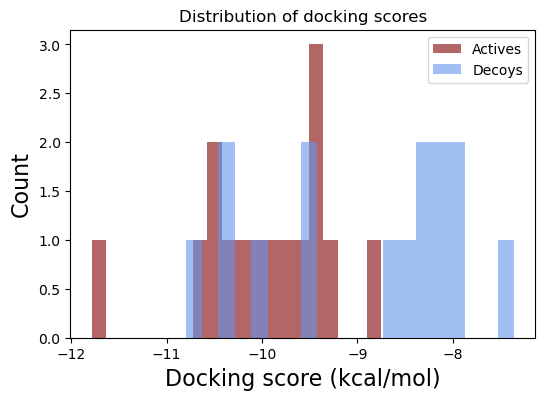

In [22]:
import matplotlib.pyplot as plt

# Load your docking results
df = pd.read_csv("results/scores/best_vina_per_ligand.csv")

# Assign labels: CHEM* = active, others = decoy
df["label"] = df["ligand"].str.startswith("CHEM").astype(int)

# Separate scores
actives = df[df.label == 1]["best_vina"]
decoys  = df[df.label == 0]["best_vina"]

# Plot histogram
plt.figure(figsize=(6,4))
plt.hist(actives, bins=20, alpha=0.6, label="Actives", color = 'maroon')
plt.hist(decoys,  bins=20, alpha=0.6, label="Decoys", color = 'cornflowerblue')
plt.xlabel("Docking score (kcal/mol)", fontsize = 16)
plt.ylabel("Count", fontsize = 16)
plt.title("Distribution of docking scores")
plt.legend()

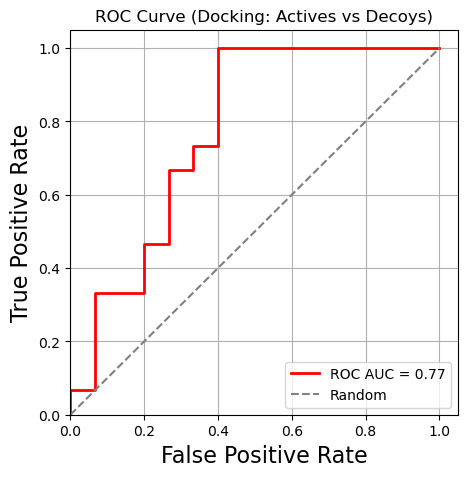

In [19]:
# in a sense, this is a classification problem, so we can give the AUC score as a reference for how well decoys and actives are
# separated in the dockng pipelines

from sklearn.metrics import roc_auc_score, roc_curve

# Load docking results
df = pd.read_csv("results/scores/best_vina_per_ligand.csv")

# Assign labels: CHEM* = active, others = decoy
df["label"] = df["ligand"].str.startswith("CHEM").astype(int)

y_true = df["label"]            # 1 = active, 0 = decoy
y_score = -df["best_vina"]      # invert scores: lower (more negative) = better

# Compute ROC and AUC
auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

# Plot ROC curve
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"ROC AUC = {auc:.2f}", color = 'red', linewidth = 2)
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random")
plt.xlabel("False Positive Rate", fontsize = 16)
plt.ylabel("True Positive Rate", fontsize = 16)
plt.title("ROC Curve (Docking: Actives vs Decoys)")
plt.legend()
plt.grid(True)
plt.xlim([0,1.05])
plt.ylim([0,1.05])

plt.savefig('auc_roc.pdf', bbox_inches = 'tight', dpi = 300)

<div style="background-color: lightyellow; padding: 10px; border-radius: 5px;">

### Outlook

- While the separation between actives and decoys is not crisp, a ROC AUC score of $0.77$ still indicates that current (simplistic) docking setup is indeed picking up a distriction between the two categories

**Limitations of docking**  
- Docking scores are *relative rankers*, not reliable absolute affinities.  
- Rigid receptors ignore induced fit.  
- Protonation/tautomer states, waters, and metal handling can shift results.

**Next steps after docking**  
- Experimental binding assays (confirm hits).  
- Higher-accuracy computations (**MD**, **MM/GBSA**, **FEP**).  
- Medicinal chemistry cycles (SAR, optimization).